In [2]:
# Linear regression is a statistical method that allows the prediction of an outcome based on the relationship between two variables.  In this case
# predictions are made using housing price based solely on the living square footage.  To build this model, a process called "train-test split"
# is used.  By using 80% of the historical prices into the algorithm it could learn the underlying pattern, with 20% of the remaining data 
# hidden.  This 20% will be used as measure for how accurately the model predicted the real-world results.  

In [3]:
# R-squared is used to measure the accuracy of the model.  Essentially R-squared represents the percentage of the prices that can be explained
# directly by the living square footage provided.  With the model achieving an accuracy of .479 or 47.9% this means that 47.9% of price  
# variation is driven by living square footage.  

In [ ]:
# How does the simple linear regression model results (using sqft_living) compare to the multiple regression we ran in the tutorial?
# The simple linear regression model is less accurate than the multiple regression model. The simple linear regression achieved a R^2 of 47.9% 
# while the multiple regression model achieved a slighly higher R^2 of 53.8%.  Relying on a single feature leaves too much unexplained variance. 
# When compared to the multiple linear regression tutorial that uses multiple relevant features the multiple regression model provides more context 
# to the algorithm, increasing reliablity and accurate pricing predictions. 

In [1]:
# Import necessary libraries for data manipulation, mathematical operations, and visualization
# pandas is used for data manipulation and analysis
# Imported matplotlib.pyplot library for the plotting of selected data
# seaborn is built on top of matplotlib and is used for the generation statistical graphics much easier
# numpy provides support for high-performance mathematical operations and multi-dimensional arrays
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [24]:
#  Imported txt file and assigned it to the variable ‘data’
data = pd.read_csv('kc_house_data.csv')

In [25]:
#  prints the first 5 lines of the dataset ‘data’
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [26]:
#  reads the datatype in the column of the dataset ‘data’
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [27]:
# Generate descriptive statistics (count, mean, std, min, max, and percentiles) for the dataset
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


<Figure size 1200x600 with 0 Axes>

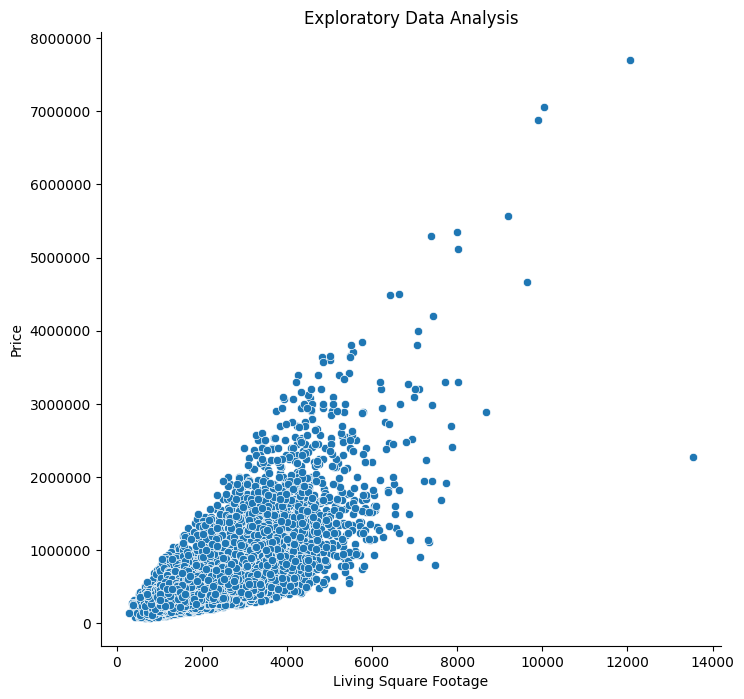

In [54]:
# Exploratory Data Analysis takes the raw values from the dataset data and plots it on a scatterplot
# Since this is not a test prediction assigned it the label Exploratory Data Analysis
# Retrieves dataset from the selection variable and assigns it to the X and Y variable for plotting as a scatterplot. 
# Creates a new plotting canvas and set its size to 12 inches wide by 6 inches tall
# Assigns 'Hours' to the X coordinate, 'Scores' to the Y coordinates, with a height of 7 as a scatterplot
# labels X,Y with a title then prints out the plot from the assigned values
plt.figure(figsize=(12,6))
sns.pairplot(data,x_vars=['sqft_living'],y_vars=['price'],height=7,kind='scatter')
plt.xlabel('Living Square Footage')
plt.ylabel('Price')
plt.title('Exploratory Data Analysis')
plt.ticklabel_format(axis="y", style="plain")
plt.show()

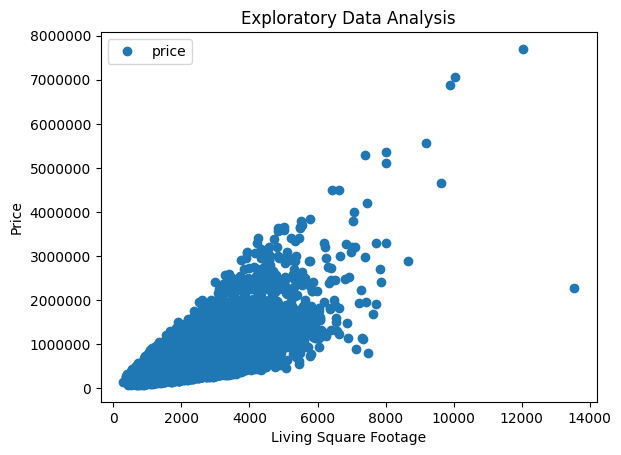

In [55]:
# Exploratory Data Analysis takes the raw values from the dataset data and plots it on a scatterplot
# Since this is not a test prediction assigned it the label Exploratory Data Analysis
# Assigns 'sqft_living' to the X coordinate, 'price' to the Y coordinates, with a style of 'o' to plot discrete plot points
# labels X,Y with a title then prints out the plot from the assigned values
data.plot(x='sqft_living', y='price', style='o')
plt.title('Exploratory Data Analysis')
plt.xlabel('Living Square Footage')
plt.ylabel('Price')
plt.ticklabel_format(axis="y", style="plain")
plt.show()

In [30]:
# Assign the 'sqft_living' column to the variable of X and prints out the first 5 lines
X = data[['sqft_living']]
X.head()

,sqft_living
0,1180
1,2570
2,770
3,1960
4,1680


In [31]:
# Print the data type of hours
type(X)

pandas.DataFrame

In [32]:
# Assign the 'Price' column to the variable of Y and prints out the first 5 lines
y = data['price']
y.head()

0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

In [33]:
# Print the data type of Scores
type(y)

pandas.Series

In [34]:
# Import the train_test_split model class from scikit-learn's library
# train_test_split is used for split arrays or matrices into random train and test subsets
from sklearn.model_selection import train_test_split

In [35]:
# Splits the data in columns X,Y and assigns train and test routines with a train_size 80% and test size 20%
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=0)

In [36]:
# Import the linear Regression model class from scikit-learn's library
# LinearRegression fits a linear model with coefficients w = (w1, …, wp) to minimize the residual sum of squares between the observed 
# targets in the dataset, and the targets predicted by the linear approximation
from sklearn.linear_model import LinearRegression

In [38]:
# Assigned lr and variables for LinearRegression 
# Train the model using our training datasets
# The .fit() method calculates the optimal line of best fit between the sqft_living and prices
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
# Use the trained model to generate predicted price (y_pred) 
# based on our testing dataset of sqft_living (X_test)
y_pred = lr.predict(X_test)

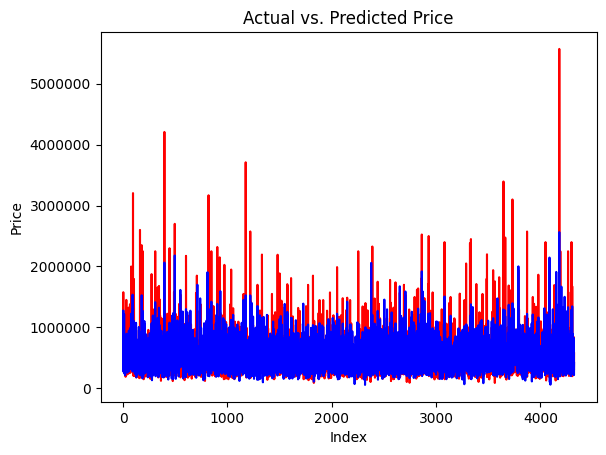

In [56]:
# Visualize the Actual Test Scores vs. the Predicted Test Scores
# Creates a index 'c' for the x-axis to line up the actual and predicted values side-by-side
# Rather than it being labeled 'sqft_living' and 'prices' it should be labled 'Actual and Predicted Scores' to represent the output of the data
c = [i for i in range (1,len(y_test)+1,1)]
plt.plot(c,y_test,color='r',linestyle='-', label='Actual Price')
plt.plot(c,y_pred,color='b',linestyle='-', label='Predicted Price')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Actual vs. Predicted Price')
plt.ticklabel_format(axis="y", style="plain")
plt.show()

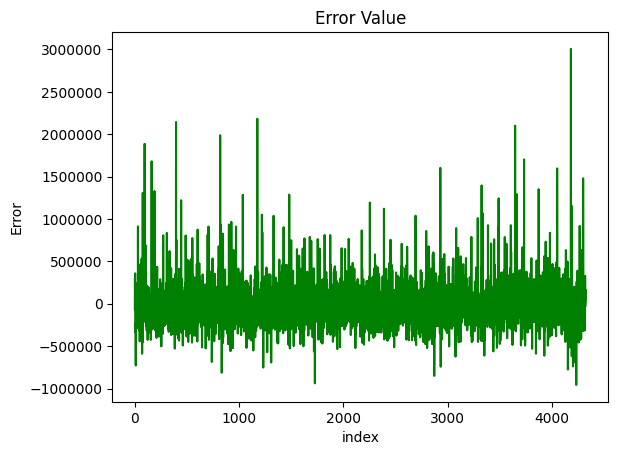

In [57]:
# Visualize the Error Values (Residuals).
# Creates a index 'c' to represent each individual sqft_living in our test set
# Plot the difference between the Actual Score and the Predicted Price (y_test - y_pred)
c = [i for i in range(1,len(y_test)+1,1)]
plt.plot(c,y_test-y_pred,color='green',linestyle='-')
plt.xlabel('index')
plt.ylabel('Error')
plt.title('Error Value')
plt.ticklabel_format(axis="y", style="plain")
plt.show()

In [43]:
# Import the metrics class from scikit-learn's library
from sklearn import metrics
# Calculate and print summary statistics to see how far off our predictions were on average (MAE, MSE, RMSE)
# Mean Absolute Error (MAE) takes all those errors, turns any negative errors into positive ones (so they don't cancel each other out), and just finds the average
# Mean Squared Error (MSE) squares every single error before averaging them. Squaring them purposefully "punishes" the model for making really big mistakes, making them highly visible
# Root Mean Squared Error (RMSE) squared the numbers, the result is in "squared points".  RMSE takes the square root to bring the number back down to normal price points
# R-Squared is an accuracy score. It tells you how well your model explains the data. Score of roughly 0.479 means the model accounted for 47.9% of the variation in the prices
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('r square :' , metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 170780.92628145573
Mean Squared Error: 61940787124.62474
Root Mean Squared Error: 248879.06124185043
r square : 0.47915772372653753


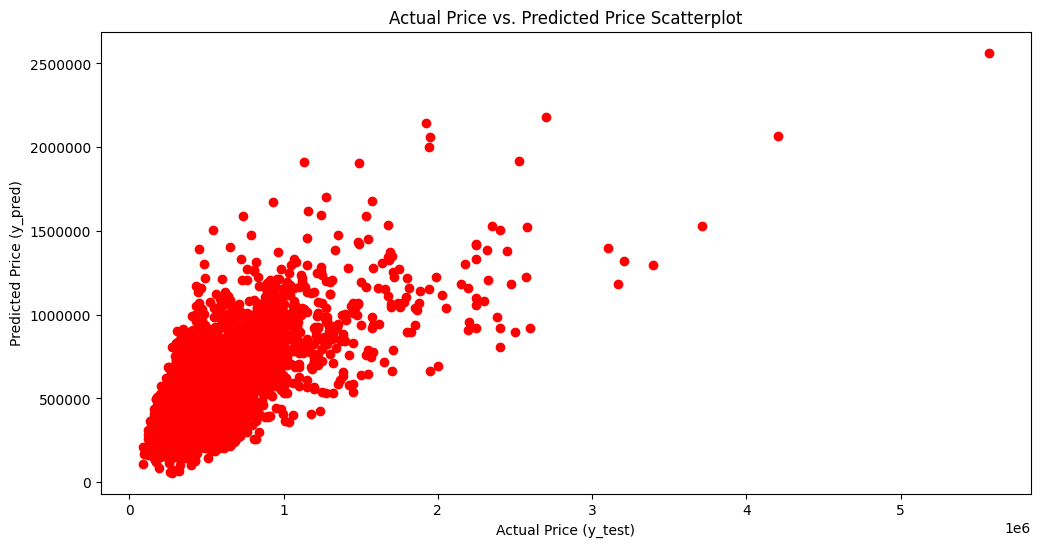

In [58]:
# Visualize the Actual Price vs. Predicted Price Scatterplot
plt.figure(figsize=(12,6))
plt.scatter(y_test,y_pred,color='r',linestyle='-')
plt.xlabel('Actual Price (y_test)')
plt.ylabel('Predicted Price (y_pred)')
plt.title('Actual Price vs. Predicted Price Scatterplot')
plt.ticklabel_format(axis="y", style="plain")
plt.show()

In [46]:
# Print the mathematical components of our line of best fit (y = mx + b)
# The Intercept is where the line crosses the y-axis (when sqft_living = 0)
# Coefficient (slope) tells how much the price is expected to increase for every 1 sqft_living
print('Intercept of the model:',lr.intercept_)
print('Coefficient of the line:',lr.coef_)

Intercept of the model: -48257.063591027516
Coefficient of the line: [283.96855716]


In [50]:
# conducted a test to evaluate the predicted values
import pandas as pd

new_hours = pd.DataFrame([[1180]], columns=['sqft_living'])

new_prediction = lr.predict(new_hours)

print("Living Square Footage:", new_hours.iloc[0]['sqft_living'])
print("Predicted Price:", new_prediction[0])

Living Square Footage: 1180
Predicted Price: 286825.8338520253
